In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
##Load dataset and dataframe
data = pd.read_csv('Housing.csv')
df = pd.DataFrame(data)
print('Loadset dataset with shape:' , df.shape)
df.head()

Loadset dataset with shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
print('\nDtypes')   ##define datatype
print(df.dtypes)


Dtypes
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [6]:
##Data cleaning Process
print('\nMissing:')   ##Chceking misiing value
print(df.isnull().sum().sort_values(ascending=False).head(30))


Missing:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
dup = df.duplicated().sum()                     ##checking duplicates 
print('\n Number of duplicates :', dup)


 Number of duplicates : 0


In [8]:
from sklearn.preprocessing import OneHotEncoder

In [9]:
oh = OneHotEncoder(sparse_output=False)

In [10]:
encoded = oh.fit_transform(df[['mainroad']])

In [11]:
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['mainroad']))

In [12]:
encoded_df

,mainroad_no,mainroad_yes
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
540,0.0,1.0
541,1.0,0.0
542,0.0,1.0
543,1.0,0.0


In [13]:
encoded = oh.fit_transform(df[['guestroom']])
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['guestroom']))
encoded_df

,guestroom_no,guestroom_yes
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0
...,...,...
540,1.0,0.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [14]:
encoded = oh.fit_transform(df[['basement']])
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['basement']))
encoded_df

,basement_no,basement_yes
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
540,0.0,1.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [15]:
encoded = oh.fit_transform(df[['hotwaterheating']])
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['hotwaterheating']))
encoded_df

,hotwaterheating_no,hotwaterheating_yes
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
540,1.0,0.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [16]:
encoded = oh.fit_transform(df[['airconditioning']])
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['airconditioning']))
encoded_df

,airconditioning_no,airconditioning_yes
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,0.0,1.0
4,0.0,1.0
...,...,...
540,1.0,0.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [17]:
encoded = oh.fit_transform(df[['parking']])
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['parking']))
encoded_df

,parking_0,parking_1,parking_2,parking_3
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
540,0.0,0.0,1.0,0.0
541,1.0,0.0,0.0,0.0
542,1.0,0.0,0.0,0.0
543,1.0,0.0,0.0,0.0


In [18]:
encoded = oh.fit_transform(df[['prefarea']])
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['prefarea']))
encoded_df

,prefarea_no,prefarea_yes
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
540,1.0,0.0
541,1.0,0.0
542,1.0,0.0
543,1.0,0.0


In [19]:
encoded = oh.fit_transform(df[['furnishingstatus']])
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['furnishingstatus']))
encoded_df

,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
540,0.0,0.0,1.0
541,0.0,1.0,0.0
542,0.0,0.0,1.0
543,1.0,0.0,0.0


In [20]:
# Identify numeric columns (int types)
num_cols = df.select_dtypes(include=['int64']).columns.tolist()

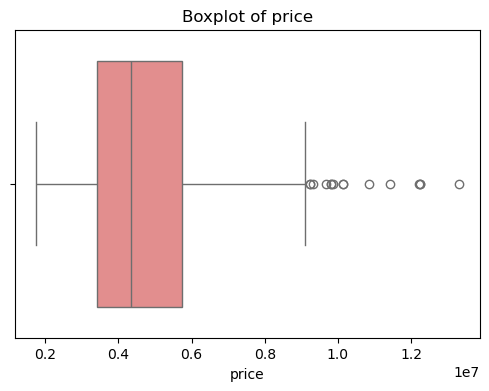

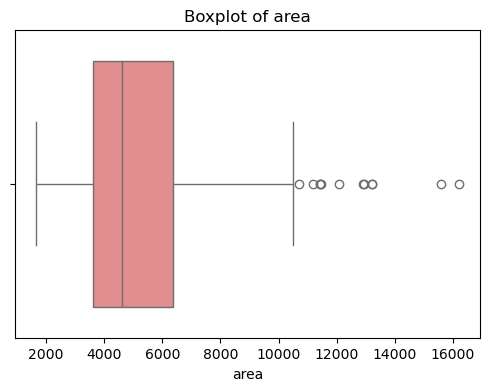

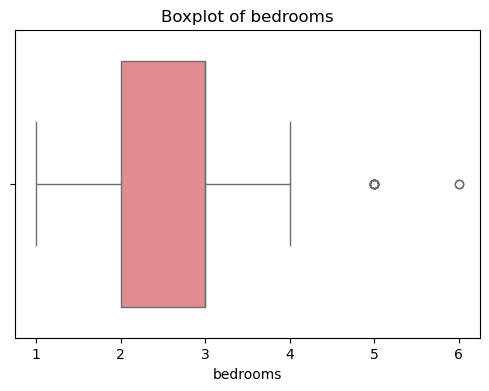

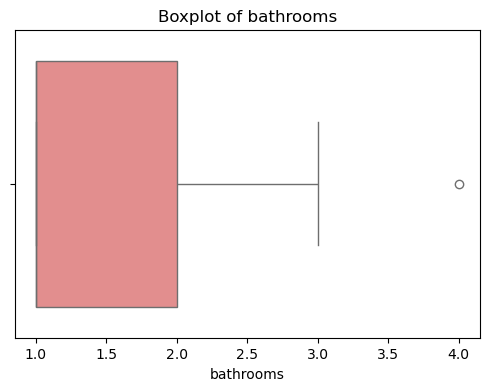

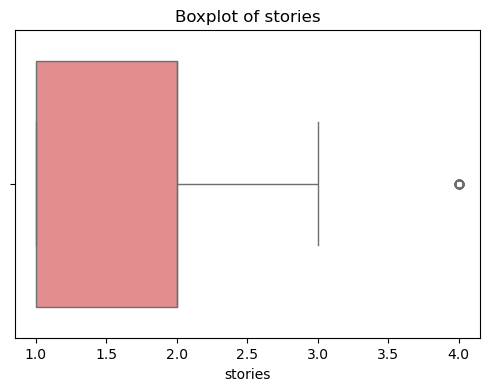

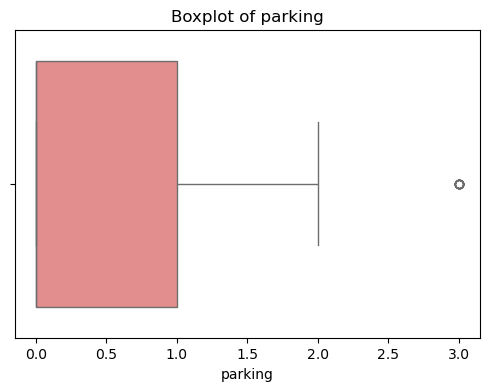

In [21]:
# Boxplots for top numerical features to visualize outliers and spread
top_num = num_cols[:6] if len(num_cols) > 6 else num_cols
for col in top_num:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.show


<Axes: >

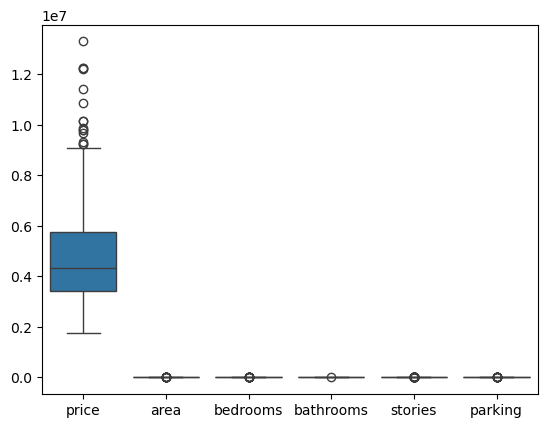

In [22]:
#Boxplot for df1 DataFrame
sns.boxplot(data=df)

In [23]:
from sklearn.preprocessing import LabelEncoder


# Copy original DataFrame to avoid modifying in place
df_encoded = df.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

# Initialize the encoder
le = LabelEncoder()

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Label encoding complete!")
print("Encoded DataFrame shape:", df_encoded.shape)
df_encoded.head()


Label encoding complete!
Encoded DataFrame shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [24]:
#Co-relation
a=df_encoded.corr(numeric_only=True)
a

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,-0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,-0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,-0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,-0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,-0.104672
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,-0.156726
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,-0.118328
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,-0.112831
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,-0.031628
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,-0.150477


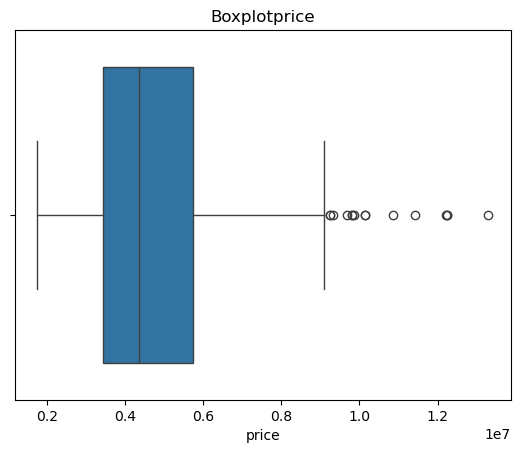

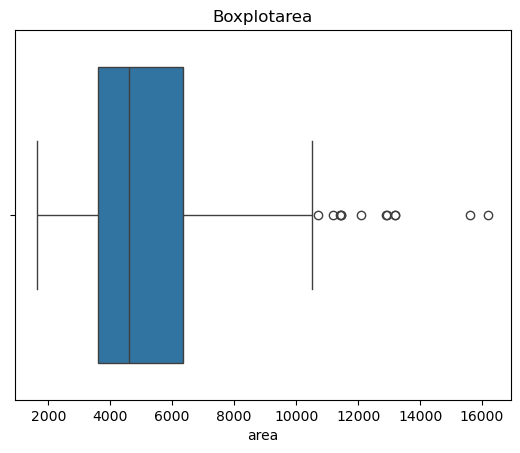

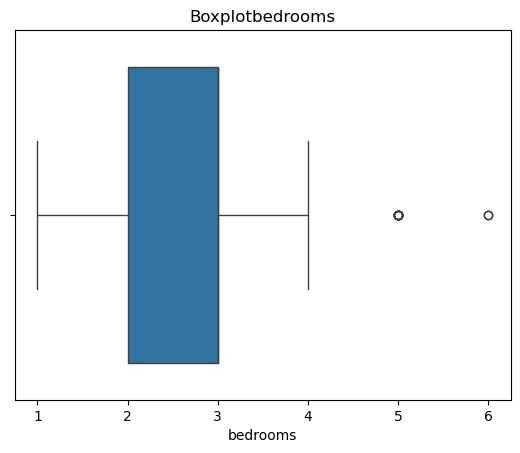

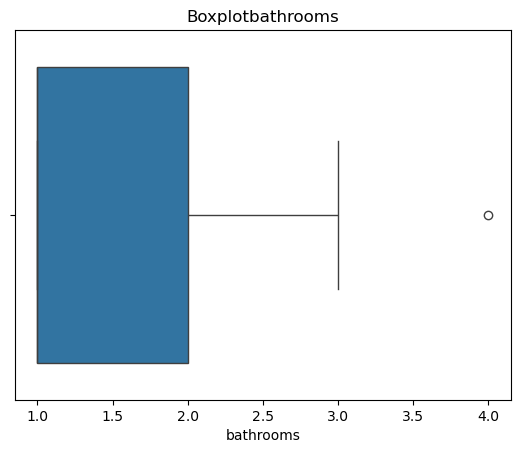

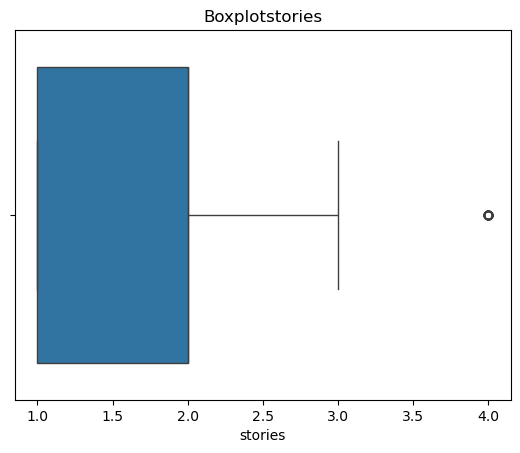

In [25]:
# boxplots for first 5 numeric
for a in num_cols[:5]:
    plt.figure(); sns.boxplot(x=df_encoded[a]); plt.title('Boxplot' + a); plt.show()

In [26]:
sns.heatmap(a,cmap='coolwarm')

ValueError: Must pass 2-d input. shape=()

In [ ]:
def handling_outliers(df, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []
    
    for col in df.select_dtypes(include='number').columns:
        if col in exclude_cols:
            continue  # skip target or excluded columns
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        
        # Capping outliers
        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound 
                                else upper_bound if x > upper_bound else x)
    return df

In [ ]:
# Apply the outlier handling function
df1 = handling_outliers(df, exclude_cols=['price'])
df1

In [ ]:
# histograms for up to 6 numeric features
if len(num_cols)>0:
    cols = num_cols[:6]
    df1[cols].hist(bins=30, layout=(3,2), figsize=(12,9)); plt.suptitle('Numeric histograms'); plt.show()

In [ ]:
#Boxplot for df1 DataFrame
sns.boxplot(data=df1)

In [ ]:
df1['price'].value_counts()

In [ ]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

In [ ]:
from  sklearn.feature_selection import SelectKBest,f_regression         # Apply SelectKBest
selector = SelectKBest(score_func=f_regression , k=13)                #select 13 features

X_new = selector.fit_transform(X,y)

#Get Select Feature names
selected_features = X.columns[selector.get_support()]

print("Top Select Features:")
print(selected_features)
